## シーングラフ（GLTF）からのボクセルの生成
- 計算結果をもとに、対応するインデックス（モートンオーダー）とメタデータについては別途DBで保持する形とする。
- メタデータはサーバで保持するのが理想だが、とりあえずはCSVで持つ方針とする

## 準備
### 計算時間の観点からEmbree(v2.17.7)は必須。事前にインストールしておく。以下を解凍して、環境変数を設定。
- https://github.com/embree/embree/releases/download/v2.17.7/embree-2.17.7.x86_64.linux.tar.gz
- source embree-vars.sh

### 依存ライブラリ
- conda install -c conda-forge trimesh
- conda install -c conda-forge pyembree
- conda install -c conda-forge tqdm
- pip install pymorton

In [33]:
import copy

import trimesh 
import numpy as np

from tqdm import tqdm

path = 'output/IfcOpenHouse.glb'
#path = 'output/TGX_Sensors.glb'
#path = 'output/ToyodaLab.glb'
scene = trimesh.load(path)
#scene = trimesh.load('output/I-REF_with_Room.glb')

In [34]:
#scene.show()

In [35]:
LOD = 1

# 0->1000mm, 1->500mm, 2->250mm 
VOXEL_SIZE_ENUM = {0:1, 1:0.5, 2:0.25, 3:0.1}
voxel_size = VOXEL_SIZE_ENUM[LOD]

voxels = dict()
transforms = dict()

# メタデータは全てここに格納されている
edges = [edge for edge in scene.graph.to_edgelist()]


def get_transform(ifc_class, transform, transforms):
    ret = np.eye(4, dtype=np.float64)
    if ifc_class in ['IfcSite', 'IfcBuilding']:
        transforms.update({ifc_class: transform})
    elif ifc_class in ['IfcBuildingStorey']:
        transforms.update({ifc_class: transform})
        del transforms['IfcSpace']
        del transforms['IfcSpatialZone']
    elif ifc_class in ['IfcSpace']:
        transforms.update({ifc_class: transform})
        del transforms['IfcSpatialZone']
    elif ifc_class in ['IfcSpatialZone']:
        transforms.update({ifc_class: transform})
    for _,v in transforms.items():
        ret = np.dot(ret, v)
    return ret

# 幅優先探索になっているはず
# 一番最初のworld, cameraは無視
for edge in tqdm(edges):
    parent = edge[0]
    name = edge[1]
    # 平行移動行列しかないので、回転行列は無視
    matrix = np.array(edge[2]['matrix'])
    # transform = np.array([a[3] for a in matrix], dtype=np.float64)[:3]

    if 'metadata' in edge[2]:
        metadata = edge[2]['metadata']
        ifc_class = metadata['type']
        transform = get_transform(ifc_class, matrix, transforms)  
        matrix = np.dot(transform, matrix)              
        if 'geometry' in edge[2]:
            geometry_name = edge[2]['geometry']
            geom = copy.deepcopy(scene.geometry[geometry_name])
            geom.apply_transform(matrix)
            voxel = geom.voxelized(voxel_size)
            #color = geom.visual.main_color/255.0
            color = geom.visual.main_color
            voxels.update({name: (metadata, color, voxel)})
            #print(name)
                   


100%|██████████| 44/44 [00:00<00:00, 138.86it/s]


In [36]:
nodes = [node for node in scene.graph.nodes_geometry]
# Initialize a scene
s = trimesh.Scene()

for node in tqdm(nodes):
    metadata, color, voxel = voxels[node]
    voxelized_mesh = voxel.as_boxes(colors=color)
    s.add_geometry(voxelized_mesh)
    
#s.show()


100%|██████████| 35/35 [00:00<00:00, 222.44it/s]


In [37]:
import pymorton as pm
import math
import json

def culc_position(t,v):
    ret = math.floor(t/voxel_size -v)
    if ret < 0:
        assert(False)    
    return ret

nodes = [node for node in scene.graph.nodes_geometry]
bounds = [int(math.floor(v/voxel_size)) for v in scene.bounds[0]]

outputs = {'voxelSize':voxel_size, 'offset':bounds}
elements = []


for node in nodes:
    if node not in voxels:
        continue
    metadata, color, voxel = voxels[node]
    metadata = copy.deepcopy(metadata)
    
    points = voxel.points
    indices = [pm.interleave3(culc_position(x,bounds[0]), culc_position(y, bounds[1]), culc_position(z, bounds[2])) for x,y,z in points]

    if 'Name' in metadata:
        name = metadata['Name']
    else:
        name = 'No Name'
    guid = metadata['GlobalId']
    cls = metadata['type']
    
    # morton orderに変換しておく（特に意味はないけれど）
    color = pm.interleave3(int(color[0]), int(color[1]), int(color[2]))

    # 邪魔なものを消す 
    del metadata['GlobalId']
    if 'Name' in metadata:
        del metadata['Name']
    del metadata['type']
    tmp = [d for d in metadata if metadata[d] == None]
    for t in tmp:
        del metadata[t]
    
    elements.append({'guid':guid,'name':name, 'class':cls, 'indices':indices, 'color':color, 'metadata':metadata})

outputs.update({'elements':elements})
    
with open('{0}.json'.format(path.split('.')[0]), mode='w') as f:
    f.write(json.dumps(outputs))


In [38]:
scene = trimesh.Scene()

def create_box(indices, color):
    group = trimesh.Trimesh()
    # Boxの色を指定するRGB値を作成
    color = pm.deinterleave3(color)
    boxes = []
    for i in indices:
        x, y, z = pm.deinterleave3(i)
        box = trimesh.creation.box(extents=[voxel_size, voxel_size, voxel_size], 
                                   transform=trimesh.transformations.translation_matrix([x*voxel_size, y*voxel_size, z*voxel_size]))

        # Boxに色を設定
        box.visual.face_colors = color
        boxes.append(box)
    return trimesh.util.concatenate(boxes)

json_load = json.load(open('{0}.json'.format(path.split('.')[0]), 'r'))
elements = json_load['elements']
for element in tqdm(elements):
    guid = element['guid']
    name = element['name']
    cls = element['class']
    indices = element['indices']
    color = element['color']
    box = create_box(indices,color)
    scene.add_geometry(box)

scene.show()

100%|██████████| 35/35 [00:04<00:00,  8.68it/s]


In [ ]:

import requests

url = 'http://localhost:9000/v1/posts'


name = path.split('/')[-1].split('.')[0]

lat = None
lon = None

# TODO 建物のメタデータは手動で入力する
payload = {'name':name, 'LOD':LOD, 'offset_x':bounds[0], 'offset_y':bounds[1], 'offset_z':bounds[2], 'latitude':lat, 'longitude':lon}
# Create BUILDING
r = requests.post(url+"/building", data=json.dumps(payload), headers={'Content-Type': 'application/json'})

#building_id = r.text
building_id = str(1)
print('BUILDING_ID: ' + building_id)



for node in nodes:
    metadata, color, voxel = voxels[node]
    
    points = voxel.points
    indices = [pm.interleave3(culc_position(x,bounds[0]), culc_position(y,bounds[1]), culc_position(z,bounds[2])) for x,y,z in points]

    if 'Name' in metadata:
        name = metadata['Name']
    else:
        name = 'No Name'
    guid = metadata['GlobalId']
    cls = metadata['type']
    
    # TODO テクスチャなどで必要になれば
    material = ""
    # morton orderに変換しておく（特に意味はないけれど）
    color = pm.interleave3(int(color[0]), int(color[1]), int(color[2]))

    payload={'name':name, 'guid':guid, 'class':cls, 'indices':indices, 'color':color, 'material':material, 'metadata':metadata}
    r = requests.put(url+"/building/" + building_id + '/object', data=json.dumps(payload), headers={'Content-Type': 'application/json'})
    print('SEND: ' + guid)




ConnectionError: HTTPConnectionPool(host='localhost', port=9000): Max retries exceeded with url: /v1/posts/building (Caused by NewConnectionError('<urllib3.connection.HTTPConnection object at 0x7fd281fca8e0>: Failed to establish a new connection: [Errno 111] Connection refused'))

/home/kasuya/miniconda3/envs/trimesh/lib/python3.8/site-packages/networkx/drawing/nx_pylab.py:433: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  node_collection = ax.scatter(
/tmp/ipykernel_840/3446798547.py:27: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  cbar = fig.colorbar(sm, shrink=0.4, ticks=[1, 0])


[Text(1, 1, 'start'), Text(1, 0, 'end')]

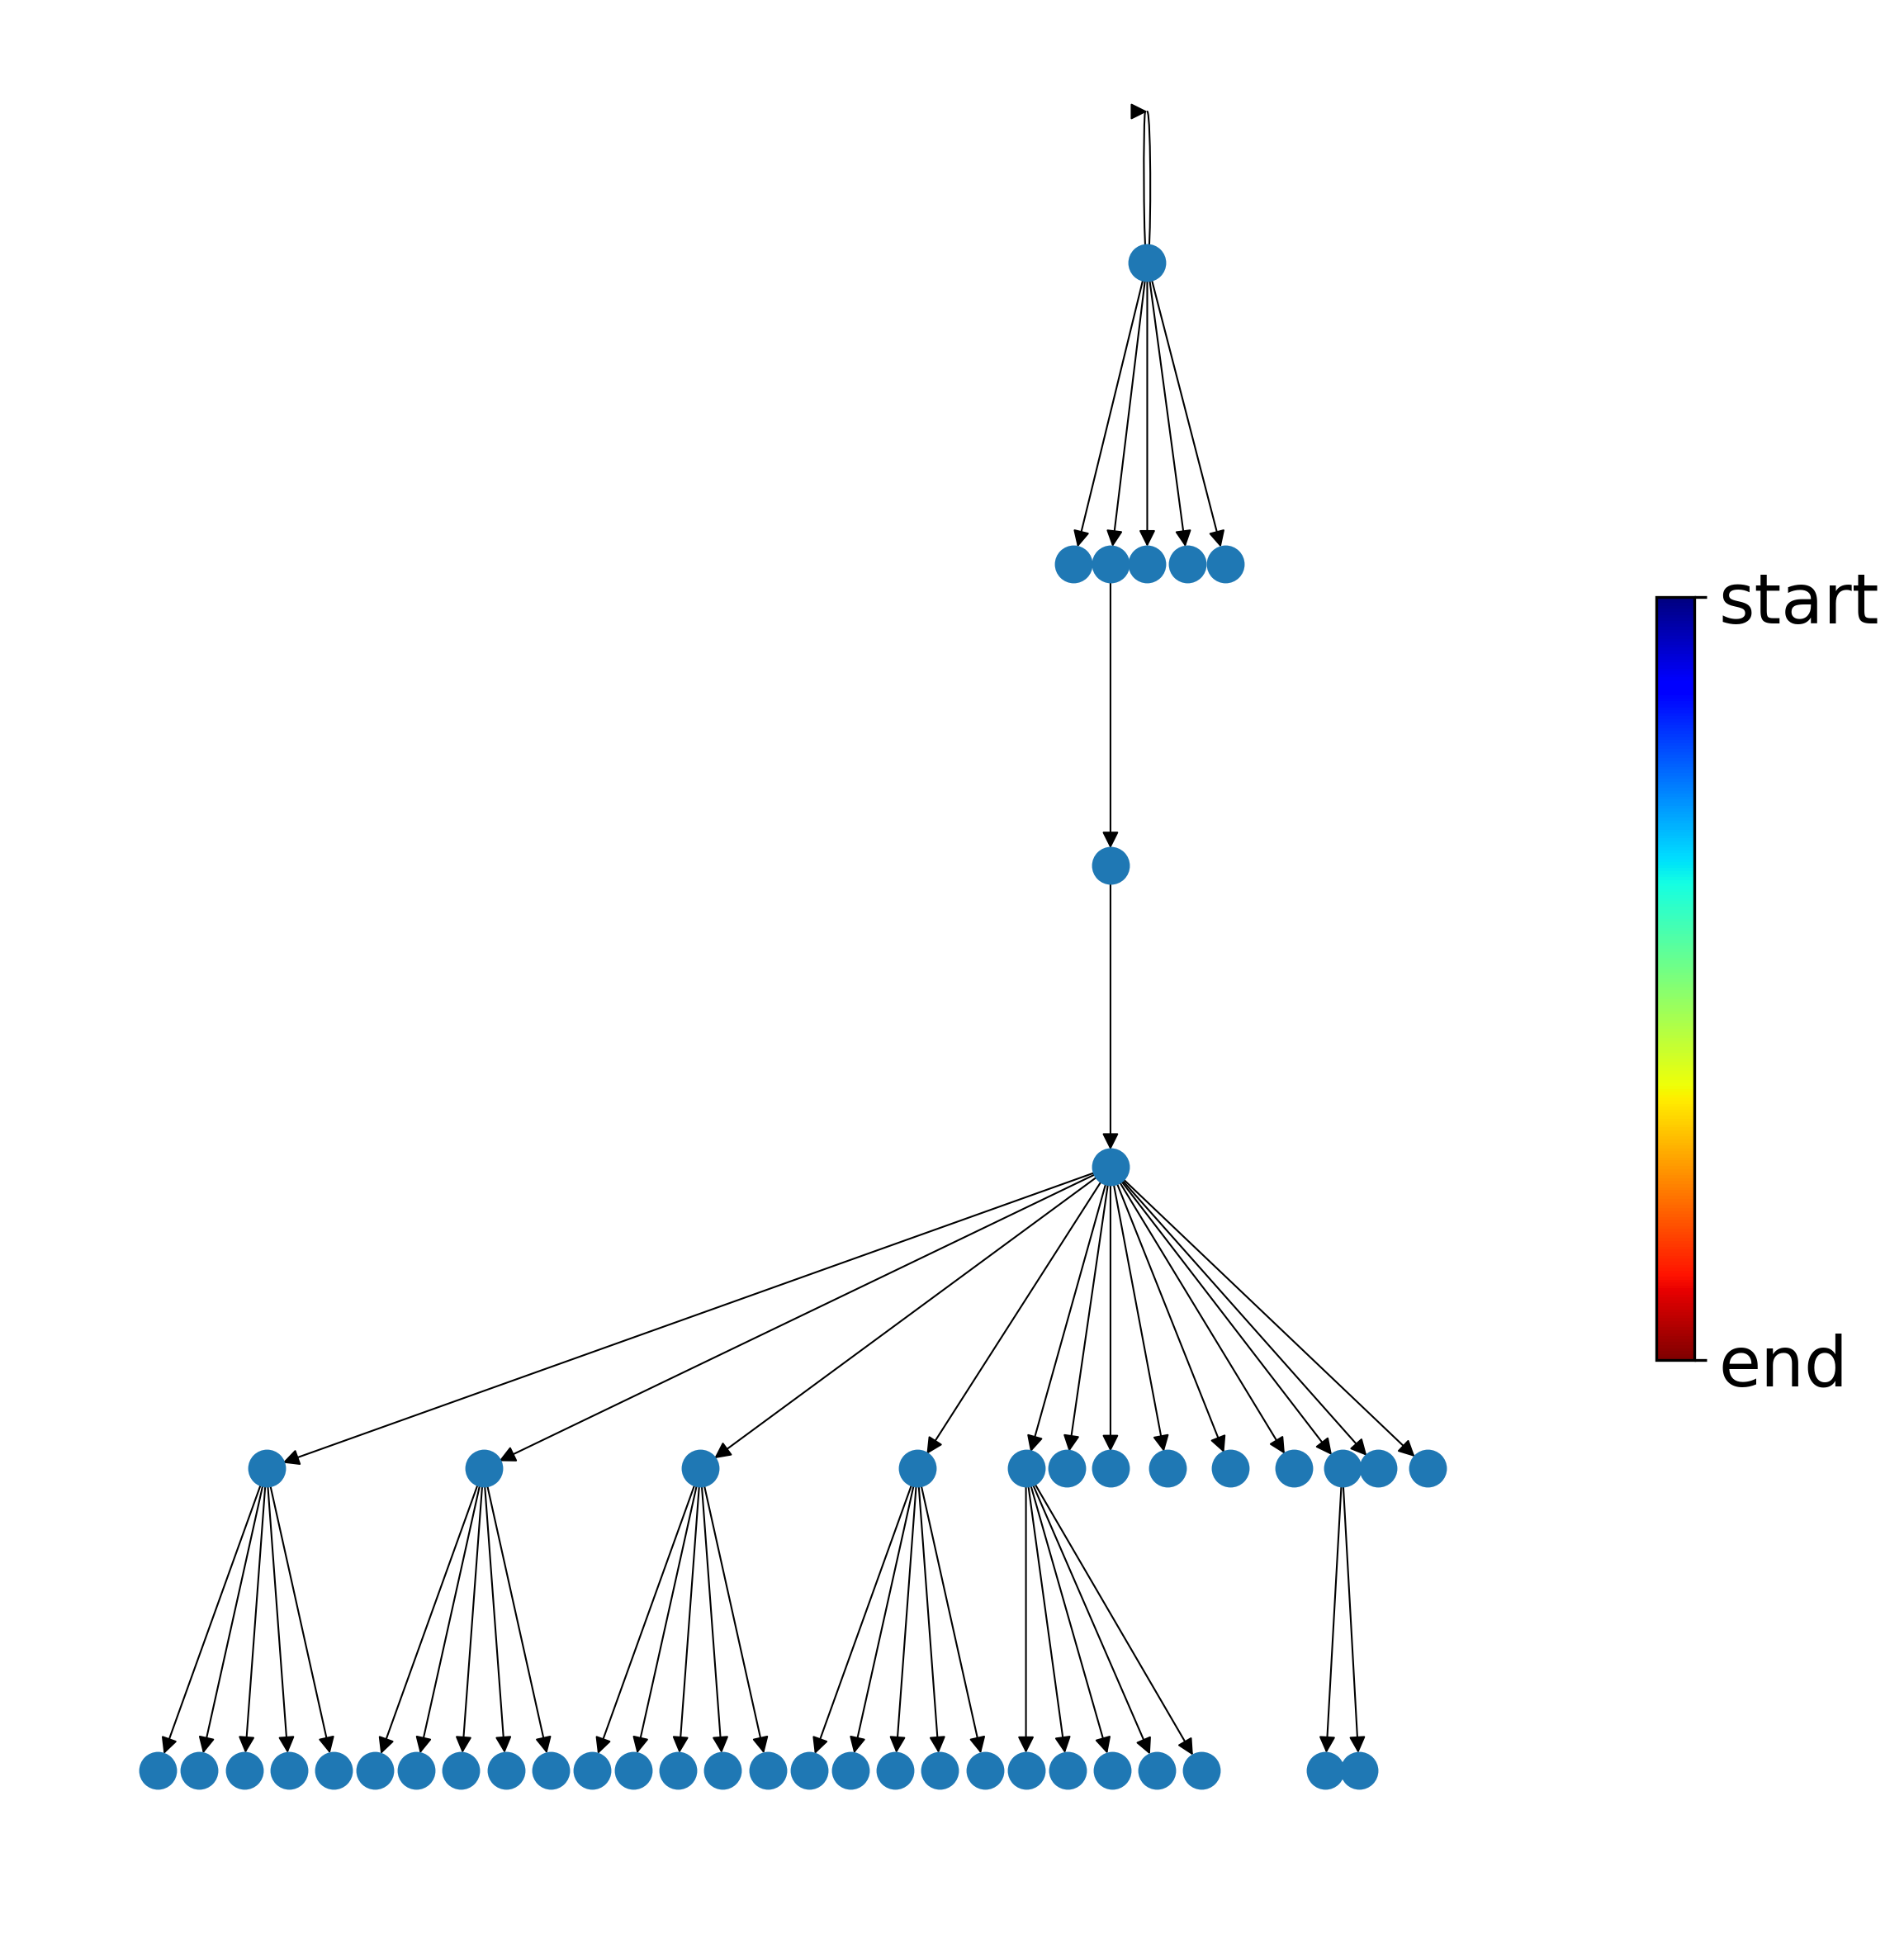

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
from networkx.drawing.nx_agraph import graphviz_layout

p = nx.drawing.nx_pydot.to_pydot(G)
pos = graphviz_layout(G, prog="dot")

# matplotlib settings
fig = plt.figure(figsize=(10, 10), dpi=300)
ax = fig.add_subplot(1, 1, 1)

# draw the network
nx.draw(G,
        ax=ax,
        pos=pos,
        with_labels=False,
        arrows=True,
        node_size=100,
        node_shape='o',
        width=0.5,

        cmap="jet")

# draw the color map bar
sm = plt.cm.ScalarMappable(cmap="jet_r", norm=plt.Normalize(vmin=0, vmax=1))
sm._A = []
cbar = fig.colorbar(sm, shrink=0.4, ticks=[1, 0])
cbar.ax.set_yticklabels(['start', 'end'], fontdict={'fontsize': 20})

In [ ]:
def get_neighbers(G, node):
    for n in nx.all_neighbors(G, node):
        yield n

for a in get_neighbers(G, 'world'):
    # ジオメトリがないものは不要
    
    for b in get_neighbers(G,a):
        print(' ', b)

  world
  world
  camera_A8FE47
  IfcSite_18
  camera_6F56B1
  light_6822FE
  light_64837E
  world
  world
  camera_A8FE47
  IfcSite_18
  camera_6F56B1
  light_6822FE
  light_64837E
  world
  world
  IfcBuilding_25
  world
  world
  world
